Eksplorasi London Crime Dataset Dari Kaggle

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import folium

Data ini tentang tindak kriminal di London, dari bulan ke bulan, per daerah, kategori, kriminalitas (major/minor), dan detail lainnya sejak Jan 2008 - Dec 2016

In [3]:
# read csv file
df = pd.read_csv('Dataset/london_crime_by_lsoa.csv')

In [3]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13490604 entries, 0 to 13490603
Data columns (total 7 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   lsoa_code       object
 1   borough         object
 2   major_category  object
 3   minor_category  object
 4   value           int64 
 5   year            int64 
 6   month           int64 
dtypes: int64(3), object(4)
memory usage: 720.5+ MB


,lsoa_code,borough,major_category,minor_category,value,year,month
0,E01001116,Croydon,Burglary,Burglary in Other Buildings,0,2016,11
1,E01001646,Greenwich,Violence Against the Person,Other violence,0,2016,11
2,E01000677,Bromley,Violence Against the Person,Other violence,0,2015,5
3,E01003774,Redbridge,Burglary,Burglary in Other Buildings,0,2016,3
4,E01004563,Wandsworth,Robbery,Personal Property,0,2008,6


Area Chart

Pertanyaan: bagaimana perubahan total tindak kejahatan yang terjadi di London dari tahun 2008 - 2016?

In [4]:
# data preprocessing
area_df = df.groupby("year", sort=True)["value"].sum()
area_df = area_df.reset_index()
area_df.columns.values[1] = "value"
area_df.head()


,year,value
0,2008,738641
1,2009,717214
2,2010,715324
3,2011,724915
4,2012,737329


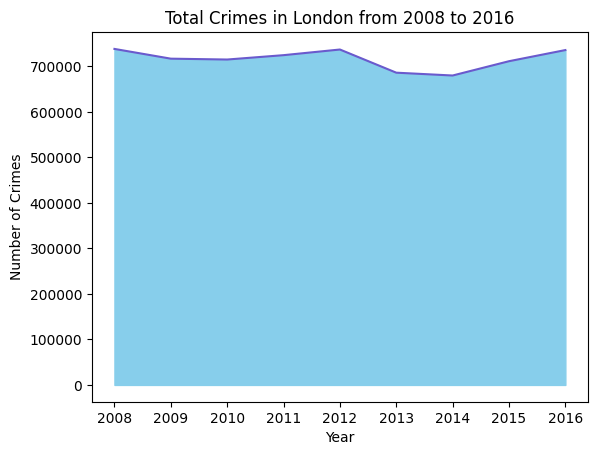

In [5]:
# plot the data
plt.fill_between(area_df['year'], area_df['value'], color="skyblue")
plt.plot(area_df['year'], area_df['value'], color="Slateblue")
plt.ylabel("Number of Crimes")
plt.xlabel("Year")
plt.title("Total Crimes in London from 2008 to 2016")
plt.show()

Jawaban: Total tindak kejahatan pada London dari tahun 2008 - 2016 tidak berubah secara signifikan, tidak terdapat kenaikan maupun penurunan yang berarti

Histogram Chart

Pertanyaan: Bagaimana perbandingan frekuensi terjadinya tindak kejahatan dengan LSOA Code E01000001 hingga E01000005 yang tercatat pada bulan November tahun 2016 di London?

In [6]:
# data preprocessing
hist_df = df.loc[(df["year"] == 2016) & (df["month"] == 11)]
hist_df = hist_df.loc[(df["lsoa_code"] == "E01000001") | 
                      (df["lsoa_code"] == "E01000002") | 
                      (df["lsoa_code"] == "E01000003") | 
                      (df["lsoa_code"] == "E01000004") | 
                      (df["lsoa_code"] == "E01000005")]
hist_df = hist_df["lsoa_code"].sort_values()
hist_df = hist_df.reset_index().drop(columns="index")
hist_df["lsoa_code"] = hist_df["lsoa_code"].str[-1:]
hist_df.head()

,lsoa_code
0,1
1,1
2,1
3,1
4,1


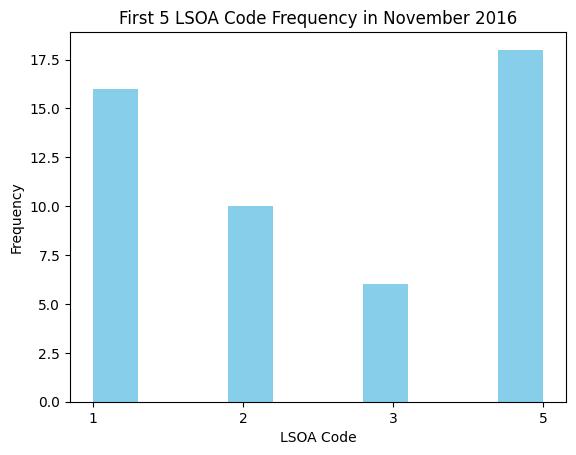

In [7]:
# plot the data
plt.hist(hist_df["lsoa_code"], color="skyblue")
plt.ylabel("Frequency")
plt.xlabel("LSOA Code")
plt.title("First 5 LSOA Code Frequency in November 2016")
plt.show()

Jawaban: Tindak kejahatan dengan LSOA Code E1000005 terjadi paling sering selama November 2016 di London sedangkan tindak kejahatan dengan LSOA Code E1000004 tidak terjadi sama sekali selama tahun November 2016 di London

Bar Chart

Pertanyaan: Dimana 10 daerah dengan total tindak kejahatan terbanyak di London selama 2008-2016?

In [7]:
# data preprocessing
bar_df = df.groupby("borough", sort=True)["value"].sum()
bar_df = bar_df.reset_index()
bar_df.columns.values[1] = "value"
bar_df.sort_values("value", ascending=False, inplace=True)
limit_df = bar_df.iloc[:10]
limit_df = limit_df.reset_index()
limit_df = limit_df.drop(columns="index")
limit_df.head()

,borough,value
0,Westminster,455028
1,Lambeth,292178
2,Southwark,278809
3,Camden,275147
4,Newham,262024


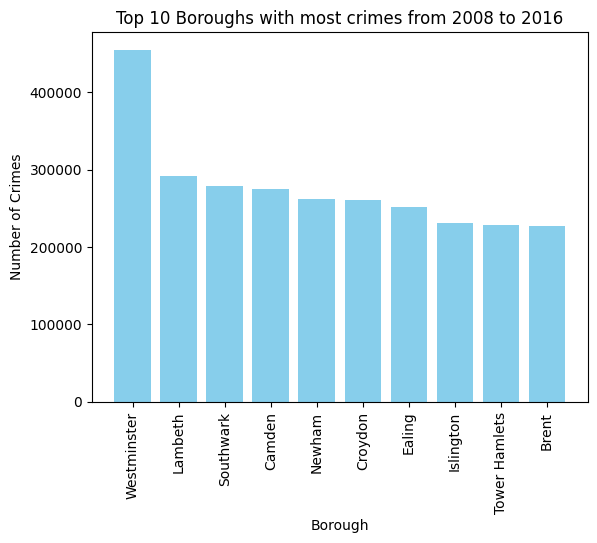

In [8]:
# plot the data
plt.bar(limit_df['borough'], limit_df['value'], color="skyblue")
plt.ylabel("Number of Crimes")
plt.xlabel("Borough")
plt.xticks(rotation=90)
plt.title("Top 10 Boroughs with most crimes from 2008 to 2016")
plt.show()

Jawaban: Westminster merupakan daerah dengan total tindak kejahatan terbanyak di London selama 2008-2016, diikuti oleh Lambeth, Southwark, Camden, Newham, Croydon, Ealing, Islington, Tower Hamlets dan Brent

Pie Chart

Pertanyaan: Bagaimana persentase tindak kejahatan dengan kategori major yang terjadi di Westminster selama 2008-2016?

In [10]:
# data preprocessing
pie_df = df.loc[df["borough"] == "Westminster"]
pie_df = pie_df.groupby("major_category", sort=True)["value"].sum()
pie_df = pie_df.reset_index()
pie_df.columns.values[1] = "value"
pie_df.info()
pie_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   major_category  9 non-null      object
 1   value           9 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 276.0+ bytes


,major_category,value
0,Burglary,29295
1,Criminal Damage,20405
2,Drugs,34031
3,Fraud or Forgery,273
4,Other Notifiable Offences,6148


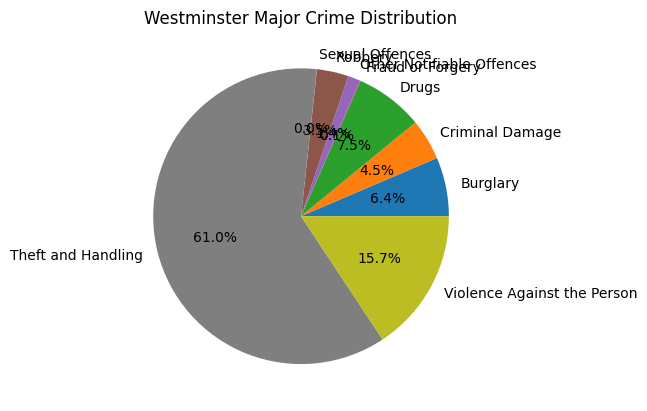

In [11]:
# plot the data
plt.pie(pie_df["value"], labels=pie_df["major_category"], autopct="%1.1f%%")
plt.title("Westminster Major Crime Distribution")
plt.show()

Jawaban: Pencurian dan penanganan menjadi kategori tindak kejahatan major dengan persentase terbesar (61%) yang terjadi di Westminster selama 2008-2016 

Box Plot

Pertanyaan: Bagaimana persebaran tingkat tindak kejahatan yang terjadi di London berdasarkan bulan selama 2008-2016?

In [12]:
# data preprocessing
box_df = df.groupby(["year", "month"], sort=True)["value"].sum()
box_df = box_df.reset_index()
box_df.info()
box_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   year    108 non-null    int64
 1   month   108 non-null    int64
 2   value   108 non-null    int64
dtypes: int64(3)
memory usage: 2.7 KB


,year,month,value
0,2008,1,65419
1,2008,2,62626
2,2008,3,61343
3,2008,4,59640
4,2008,5,62587


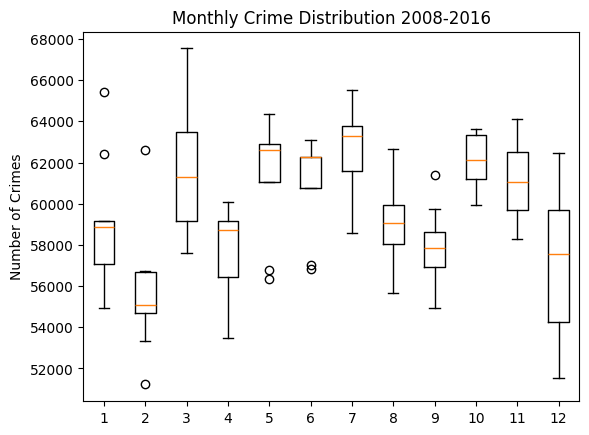

In [13]:
# plot the data
plt.boxplot([box_df[box_df["month"]==1]["value"], 
             box_df[box_df["month"]==2]["value"], 
             box_df[box_df["month"]==3]["value"], 
             box_df[box_df["month"]==4]["value"], 
             box_df[box_df["month"]==5]["value"], 
             box_df[box_df["month"]==6]["value"], 
             box_df[box_df["month"]==7]["value"], 
             box_df[box_df["month"]==8]["value"], 
             box_df[box_df["month"]==9]["value"], 
             box_df[box_df["month"]==10]["value"], 
             box_df[box_df["month"]==11]["value"], 
             box_df[box_df["month"]==12]["value"]])
plt.ylabel("Number of Crimes")
plt.title("Monthly Crime Distribution 2008-2016")
plt.show()

Jawaban: Selama tahun 2008-2016 bulan dengan tingkat tindak kejahatan paling rendah biasanya terjadi pada bulan Februari dan bulan dengan tindak kejahatan paling tinggi biasanya terjadi pada bulan Juli

Scatter Plot

Pertanyaan: Bagaimana distribusi tindak kejahatan yang terjadi setiap bulannya selama 2008 di London?

In [ ]:
# data preprocessing
scatter_df = df.loc[(df["year"] == 2008)]
scatter_df = scatter_df.groupby("month", sort=True)["value"].sum()
scatter_df = scatter_df.reset_index()
scatter_df.columns.values[1] = "value"
scatter_df.head()


,month,value
0,1,65419
1,2,62626
2,3,61343
3,4,59640
4,5,62587


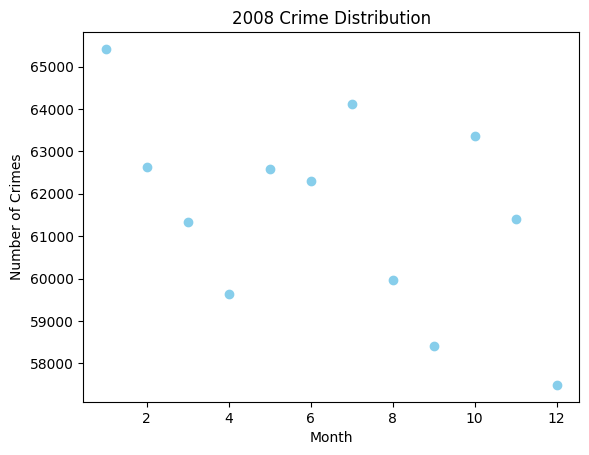

In [5]:
# plot the data
plt.scatter(scatter_df["month"], scatter_df["value"], color="skyblue")
plt.ylabel("Number of Crimes")
plt.xlabel("Month")
plt.title("2008 Crime Distribution")
plt.show()

Jawaban: Januari menjadi bulan paling banyak tindak kejahatan selama 2008 dan Desember menjadi bulan paling sedikit tindak kejahatan selama 2008 di London

Word Clouds

Pertanyaan: Tindak kejahatan dengan kategori minor apa yang paling sering muncul selama tahun 2008-2016 di London?

In [14]:
# data preprocessing
stopwords = set(STOPWORDS)
text = pd.read_csv('Dataset/london_crime_by_lsoa.csv', usecols=["minor_category"])

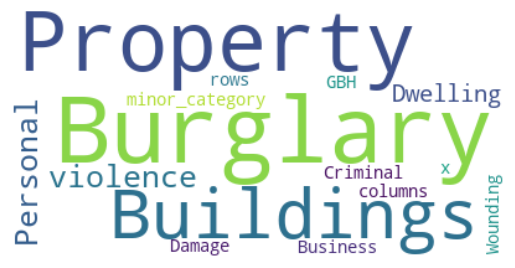

In [15]:
# plot the data
words = WordCloud(background_color="white", stopwords=stopwords).generate(str(text))
plt.imshow(words, interpolation="bilinear")
plt.axis("off")
plt.show()

Jawaban: Tindak kejahatan yang melibatkan perampokan, properti dan gedung menjadi kategori yang paling sering muncul selama 2008-2016 di London

Folium Maps

Pertanyaan: Bagaimana peta dari London?

In [16]:
# create a map
london_map = folium.Map(location=[51.5074, 0.1278], zoom_start=10)
london_map

Jawaban: Berikuta adalah peta dari London